In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib

In [2]:
np.random.seed(42)

n = 10000

categories = ["Coding", "Fitness", "Study", "Health", "Mind", "Career"]
difficulties = ["Easy", "Medium", "Hard", "Epic"]

df = pd.DataFrame({
    "quest_category": np.random.choice(categories, n),
    "difficulty": np.random.choice(difficulties, n),
    "estimated_time": np.random.randint(10, 121, n),
    "completion_rate": np.round(np.random.uniform(0.2, 1.0, n), 2),
    "streak": np.random.randint(0, 31, n),
    "avg_xp": np.random.randint(20, 251, n),
    "hour": np.random.randint(6, 24, n),
    "previous_completed": np.random.randint(0, 2, n)
})

df.head()

,quest_category,difficulty,estimated_time,completion_rate,streak,avg_xp,hour,previous_completed
0,Health,Easy,89,0.60,18,35,9,1
1,Mind,Epic,11,0.32,3,145,12,1
2,Study,Medium,102,0.59,28,126,6,0
3,Mind,Epic,77,0.31,16,22,13,0
4,Mind,Epic,59,0.55,21,123,16,1


In [3]:
# Difficulty effect
difficulty_score = df["difficulty"].map({
    "Easy": 0.20,
    "Medium": 0.10,
    "Hard": -0.05,
    "Epic": -0.15
})

# Category effect
category_score = df["quest_category"].map({
    "Coding": 0.05,
    "Fitness": 0.03,
    "Study": 0.04,
    "Health": 0.02,
    "Mind": 0.03,
    "Career": 0.01
})

score = (
    0.35
    + df["completion_rate"] * 0.45
    + df["streak"] * 0.005
    + df["previous_completed"] * 0.10
    - df["estimated_time"] * 0.0015
    + difficulty_score
    + category_score
)

score = np.clip(score, 0.05, 0.95)

df["completed"] = np.random.binomial(1, score)

df.head()


,quest_category,difficulty,estimated_time,completion_rate,streak,avg_xp,hour,previous_completed,completed
0,Health,Easy,89,0.60,18,35,9,1,1
1,Mind,Epic,11,0.32,3,145,12,1,1
2,Study,Medium,102,0.59,28,126,6,0,0
3,Mind,Epic,77,0.31,16,22,13,0,0
4,Mind,Epic,59,0.55,21,123,16,1,0


In [4]:
df["completed"].value_counts()

completed
1    6867
0    3133
Name: count, dtype: int64

In [5]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df["completed"].value_counts(normalize=True))

Dataset shape: (10000, 9)

Missing values:
quest_category        0
difficulty            0
estimated_time        0
completion_rate       0
streak                0
avg_xp                0
hour                  0
previous_completed    0
completed             0
dtype: int64

Data types:
quest_category         object
difficulty             object
estimated_time          int64
completion_rate       float64
streak                  int64
avg_xp                  int64
hour                    int64
previous_completed      int64
completed               int64
dtype: object

Target distribution:
completed
1    0.6867
0    0.3133
Name: proportion, dtype: float64


In [6]:
X = df.drop("completed", axis=1)
y = df["completed"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 8)
y shape: (10000,)


In [7]:
categorical_features = [
    "quest_category",
    "difficulty"
]

numerical_features = [
    "estimated_time",
    "completion_rate",
    "streak",
    "avg_xp",
    "hour",
    "previous_completed"
]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

In [10]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8000, 8)
Testing : (2000, 8)


In [12]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [13]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

In [14]:
y_pred

array([1, 1, 0, ..., 0, 0, 1], shape=(2000,))

In [15]:
y_probability

array([0.64914678, 0.83656712, 0.42196326, ..., 0.41634352, 0.48000684,
       0.75185974], shape=(2000,))

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.6925
Precision: 0.782
Recall   : 0.7655
F1 Score : 0.7736
ROC-AUC  : 0.7206


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.53      0.52       627
           1       0.78      0.77      0.77      1373

    accuracy                           0.69      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.70      0.69      0.69      2000



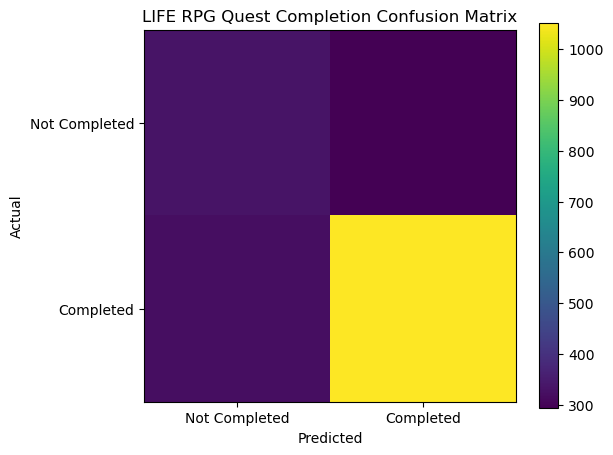

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LIFE RPG Quest Completion Confusion Matrix")

plt.colorbar()

plt.xticks([0, 1], ["Not Completed", "Completed"])
plt.yticks([0, 1], ["Not Completed", "Completed"])

plt.show()

In [19]:
new_quest = pd.DataFrame({
    "quest_category": ["Coding"],
    "difficulty": ["Medium"],
    "estimated_time": [60],
    "completion_rate": [0.82],
    "streak": [12],
    "avg_xp": [65],
    "hour": [20],
    "previous_completed": [1]
})

In [20]:
prediction = model.predict(new_quest)[0]

probability = model.predict_proba(new_quest)[0][1]

print("Prediction:", prediction)
print("Completion likelihood:", round(probability * 100, 2), "%")

Prediction: 1
Completion likelihood: 89.74 %


In [21]:
def recommend_quests(user_features, available_quests, top_n=5):
    
    recommendations = available_quests.copy()

    # Add user behavior to every quest
    for column, value in user_features.items():
        recommendations[column] = value

    # Predict completion probability
    recommendations["completion_likelihood"] = (
        model.predict_proba(
            recommendations[
                [
                    "quest_category",
                    "difficulty",
                    "estimated_time",
                    "completion_rate",
                    "streak",
                    "avg_xp",
                    "hour",
                    "previous_completed"
                ]
            ]
        )[:, 1]
    )

    # Convert to percentage
    recommendations["completion_likelihood"] = (
        recommendations["completion_likelihood"] * 100
    )

    # Highest probability first
    recommendations = recommendations.sort_values(
        "completion_likelihood",
        ascending=False
    )

    return recommendations.head(top_n)

In [22]:
available_quests = pd.DataFrame({
    "quest_category": [
        "Coding",
        "Study",
        "Coding",
        "Fitness",
        "Health",
        "Mind",
        "Career"
    ],
    "difficulty": [
        "Medium",
        "Easy",
        "Hard",
        "Easy",
        "Medium",
        "Easy",
        "Medium"
    ],
    "estimated_time": [
        60,
        30,
        90,
        30,
        45,
        20,
        60
    ],
    "avg_xp": [
        70,
        40,
        100,
        30,
        50,
        30,
        60
    ]
})

available_quests

,quest_category,difficulty,estimated_time,avg_xp
0,Coding,Medium,60,70
1,Study,Easy,30,40
2,Coding,Hard,90,100
3,Fitness,Easy,30,30
4,Health,Medium,45,50
5,Mind,Easy,20,30
6,Career,Medium,60,60


In [23]:
user_features = {
    "completion_rate": 0.82,
    "streak": 12,
    "avg_xp": 65,
    "hour": 20,
    "previous_completed": 1
}

recommendations = recommend_quests(
    user_features,
    available_quests,
    top_n=5
)


recommendations

,quest_category,difficulty,estimated_time,avg_xp,completion_rate,streak,hour,previous_completed,completion_likelihood
3,Fitness,Easy,30,65,0.82,12,20,1,98.244955
1,Study,Easy,30,65,0.82,12,20,1,94.756593
5,Mind,Easy,20,65,0.82,12,20,1,93.979058
0,Coding,Medium,60,65,0.82,12,20,1,89.744332
6,Career,Medium,60,65,0.82,12,20,1,83.313352


In [24]:
import os

os.makedirs("../backend/app/ml", exist_ok=True)

joblib.dump(
    model,
    "../backend/app/ml/life_rpg_recommender.pkl"
)

print("Model saved successfully!")

Model saved successfully!
